In [601]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
from scipy import optimize

In [602]:
n = 1000

v_x = 1 * np.random.rand(n) - 0.5
v_y = 1 * np.random.rand(n) - 0.5

mean = 0
pair_count = 0
for i in range(n):
  for j in range(i, n):
    if i == j:
      continue
    vr_x = v_x[i] - v_x[j]
    vr_y = v_y[i] - v_y[j]

    vr = np.sqrt(vr_x**2 + vr_y**2)
    mean += vr
    pair_count += 1

print(pair_count)
print(mean / (n * (n - 1) / 2))

499500
0.5210090148682287


In [ ]:
# the final temperature from a uniformly distributed speed
m = 1 * u.kg
v_max = 0.5 * u.m / u.s
T_f = (m * v_max**2 / (9 * c.k_B)).to(u.K)


def f_M(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * c.k_B.value * T))**(3/2) * np.exp(- m * v**2 / (2 * c.k_B.value * T))


def f_M_v(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * c.k_B.value * T))**(3/2) * np.exp(- m * v**2 / (2 * c.k_B.value * T))


def uniform_dist(v, v_max):
  # zeros = np.zeros_like(v)[np.where(v < v_max)[0]]
  initial = np.ones_like(v)
  initial[np.where(v > v_max)[0]] = 0
  return 1 / v_max * initial

In [615]:
speed_range = np.linspace(0, 1, 1000) * u.m/ u.s
n = 1000
sigma = 1
nu_c = n
nu = nu_c / 2

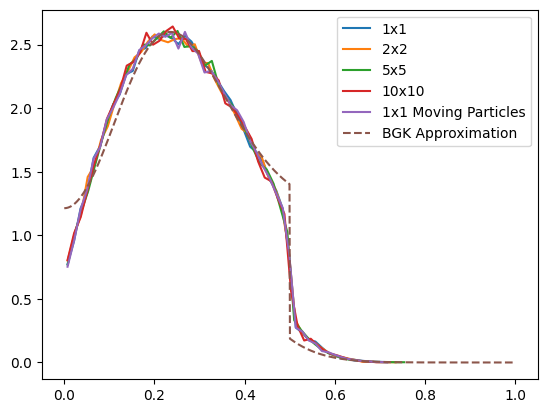

In [613]:
nx_vals = np.array([1, 2, 5, 10])
ny_vals = [1, 2, 5, 10]
vals = []
plt.figure()
for i, nx in enumerate(nx_vals):
  # for j, ny in enumerate(ny_vals):
  data = pd.read_csv(f"refinement/testing_{nx:d}x{nx:d}_particles_0100.csv")
  speed = np.sqrt(data["v_x"]**2 + data["v_y"]**2 + data["v_z"]**2)
  hist, edges = np.histogram(speed, bins=50, density=True)
  centers = (edges[1:] + edges[:-1]) / 2

  plt.plot(centers,hist,label=f"{nx:d}x{nx:d}")

data = pd.read_csv(f"testing_out_particles_0100.csv")
speed = np.sqrt(data["v_x"]**2 + data["v_y"]**2 + data["v_z"]**2)
hist, edges = np.histogram(speed, bins=50, density=True)
centers = (edges[1:] + edges[:-1]) / 2

plt.plot(centers,hist,label=f"1x1 Moving Particles")

bgk = lambda v, nu, t: f_M(v, T_f.value, m.value) + np.exp(-nu * t) * (uniform_dist(v, v_max.value) - f_M(v, T_f.value, m.value))
plt.plot(speed_range, bgk(speed_range.value, nu / 1000, 1e-2 * 100), '--', label="BGK Approximation")

plt.legend()
plt.show()


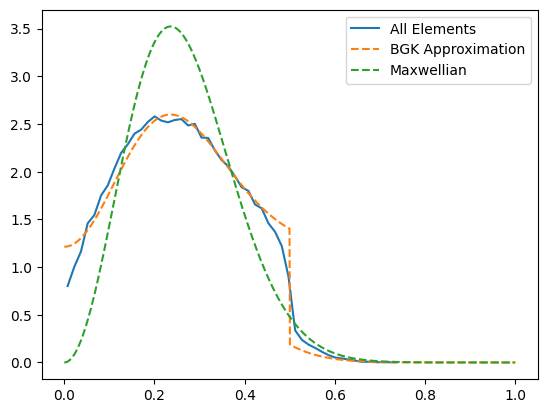

In [ ]:
# data = pd.read_csv("refinement/testing_2x2_particles_0100.csv")

# speed = np.sqrt(data["v_x"]**2 + data["v_y"]**2 + data["v_z"]**2)
# hist_all, edges = np.histogram(speed, bins=50, density=True)
# centers_all = (edges[1:] + edges[:-1]) / 2

# data = pd.read_csv("refinement/testing_10x10_particles_0100.csv")
# speed = np.sqrt(data["v_x"]**2 + data["v_y"]**2 + data["v_z"]**2)
# hist_all, edges = np.histogram(speed, bins=50, density=True)
# centers_all = (edges[1:] + edges[:-1]) / 2

# plt.figure()

# # for i in range(4):
# #   elem_data = data[data["elem_id"] == i]
# #   speed = np.sqrt(elem_data["v_x"]**2 + elem_data["v_y"]**2 + elem_data["v_z"]**2)
# #   hist, edges = np.histogram(speed, bins=50, density=True)
# #   centers = (edges[1:] + edges[:-1]) / 2
# #   mid_idx = np.where(centers >= 0.25)[0][0]
# #   # print(i, hist[mid_idx])
# #   vals.append(hist[mid_idx])
# #   # plt.plot(centers[mid_idx], hist[mid_idx], 'o')
# #   plt.plot(centers,hist,label=f"Elem id: {i:d}")

# bgk = lambda v, nu, t: f_M(v, T_f.value, m.value) + np.exp(-nu * t) * (uniform_dist(v, v_max.value) - f_M(v, T_f.value, m.value))
# # plt.plot(speed_range, uniform_dist(speed_range, v_max), '--', c='tab:blue')


# plt.plot(speed_range, bgk(speed_range.value, nu / 1000, 1e-2 * 100), '--', label="BGK Approximation")
# plt.plot(speed_range, f_M(speed_range.value, T_f.value, m.value), '--', label='Maxwellian')
# plt.legend()
# plt.show()